In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler#%%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from catboost import Pool, CatBoostRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import lightgbm as lgb
%matplotlib inline

# Determining the cost of cars

The service for selling used cars “Not a Bit, Not a Paint” is developing an application to attract new customers. Here you can quickly find out the market value of your car. We have historical data at our disposal: technical characteristics, configurations and prices of cars. We need to build a model to determine the cost.

The following are important to the customer:

- quality of prediction;
- prediction speed;
- training time.

## Data preparation

We will upload the data and do an initial inspection.

In [2]:
data = pd.read_csv('/datasets/autos.csv')
data_copy = data
data

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
354364,2016-03-21 09:50:58,0,NaN,2005,manual,0,colt,150000,7,petrol,mitsubishi,yes,2016-03-21 00:00:00,0,2694,2016-03-21 10:42:49
354365,2016-03-14 17:48:27,2200,NaN,2005,NaN,0,NaN,20000,1,NaN,sonstige_autos,NaN,2016-03-14 00:00:00,0,39576,2016-04-06 00:46:52
354366,2016-03-05 19:56:21,1199,convertible,2000,auto,101,fortwo,125000,3,petrol,smart,no,2016-03-05 00:00:00,0,26135,2016-03-11 18:17:12
354367,2016-03-19 18:57:12,9200,bus,1996,manual,102,transporter,150000,3,gasoline,volkswagen,no,2016-03-19 00:00:00,0,87439,2016-04-07 07:15:26


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Kilometer          354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  Repaired           283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

The data is not in its pure form, there are both type conversion errors and omissions in the data, we will correct them!

In [4]:
data.describe()

,Price,RegistrationYear,Power,Kilometer,RegistrationMonth,NumberOfPictures,PostalCode
count,354369.000000,354369.000000,354369.000000,354369.000000,354369.000000,354369.0,354369.000000
mean,4416.656776,2004.234448,110.094337,128211.172535,5.714645,0.0,50508.689087
std,4514.158514,90.227958,189.850405,37905.341530,3.726421,0.0,25783.096248
min,0.000000,1000.000000,0.000000,5000.000000,0.000000,0.0,1067.000000
25%,1050.000000,1999.000000,69.000000,125000.000000,3.000000,0.0,30165.000000
50%,2700.000000,2003.000000,105.000000,150000.000000,6.000000,0.0,49413.000000
75%,6400.000000,2008.000000,143.000000,150000.000000,9.000000,0.0,71083.000000
max,20000.000000,9999.000000,20000.000000,150000.000000,12.000000,0.0,99998.000000


Let’s analyze specifically which features we have gaps in.

In [5]:
data.isna().sum()

DateCrawled              0
Price                    0
VehicleType          37490
RegistrationYear         0
Gearbox              19833
Power                    0
Model                19705
Kilometer                0
RegistrationMonth        0
FuelType             32895
Brand                    0
Repaired             71154
DateCreated              0
NumberOfPictures         0
PostalCode               0
LastSeen                 0
dtype: int64

First of all, let's correct the most obvious type casting error - the *Repaired* sign, it should be cast to the Bool type, first fill in the gaps with the value False, since if the field is empty, most likely the users meant that it was not repaired, so they did not enter anything.

In [6]:
tmp_repaired = [True if i == 'yes' else False for i in data['Repaired']]

In [7]:
data['Repaired'] = tmp_repaired

Let's remove the following signs: *NumberOfPictures* - it contains only zeros and does not carry any information, *DateCrawled*, *DateCreated*, *LastSeen*, *PostalCode* - signs that do not affect the price in any way.

In [8]:
data = data.drop(["DateCrawled","DateCreated","LastSeen","NumberOfPictures","PostalCode"], axis=1)

The rest of the signs are a little more difficult - they are all categorical. Of course, you can try to restore them based on other data, for example, restore the type of equipment by brand and engine power, but it is better to coordinate such a grouping with the customer or ask more experienced colleagues. Therefore, for now we will fill in the blanks with “unknown”.

In [9]:
data['VehicleType'] = data['VehicleType'].fillna('unknown')
data['Gearbox'] = data['Gearbox'].fillna('unknown')
data['Model'] = data['Model'].fillna('unknown')
data['FuelType'] = data['FuelType'].fillna('unknown')

It's time to deal with anomalous values.

In [10]:
data['RegistrationYear']

0         1993
1         2011
2         2004
3         2001
4         2008
          ... 
354364    2005
354365    2005
354366    2000
354367    1996
354368    2002
Name: RegistrationYear, Length: 354369, dtype: int64

In [11]:
data.loc[data['RegistrationMonth'] == 0, 'RegistrationMonth'] = 1
data.loc[data['Power'] > 3000, 'Power'] = 3000
data["RegistrationYear"] = data["RegistrationYear"].where(data["RegistrationYear"] < pd.to_datetime(data_copy['DateCreated']).dt.year, pd.to_datetime(data_copy['DateCreated']).dt.year)
data["RegistrationYear"] = data["RegistrationYear"].where(data["RegistrationYear"] > 1940, 1940)

In [12]:
data['RegistrationYear'].sort_values()

33638     1940
117371    1940
225151    1940
26216     1940
79120     1940
          ... 
275220    2016
127981    2016
176228    2016
71083     2016
289428    2016
Name: RegistrationYear, Length: 354369, dtype: int64

Now let's deal with emissions. Let's build a range diagram and evaluate the situation.

(-50.0, 20000.0)

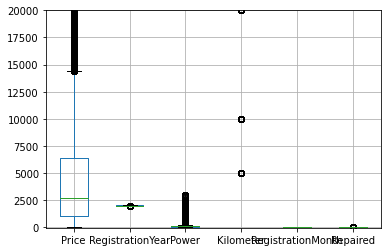

In [13]:
data.boxplot()
plt.ylim(-50, 20000)

As it turned out, there are a lot of outliers; they need to be processed in the *Price* and *Power* attributes.

Let's process outliers.

In [14]:
count = 0
index_del = []
for column in ["Price","Power"]:
    q25=np.array(data[column].quantile(0.25))
    q75=np.array(data[column].quantile(0.75))
    first_part=q25-1.5*(q75-q25)
    second_part=q75+1.5*(q75-q25)
    for index_value, value in zip(data[column].index,data[column]):
        if second_part <= value or value <= first_part:
            index_del.append(index_value)
    count += len(index_del)
    data = data.drop(index_del, axis = 0)
    index_del = []

## Model training

Let's divide it into features and targets.

In [15]:
features_NEW = data.drop('Price', axis=1)
target_NEW = data['Price']
features_NEW

,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired
0,unknown,1993,manual,0,golf,150000,1,petrol,volkswagen,False
2,suv,2004,auto,163,grand,125000,8,gasoline,jeep,False
3,small,2001,manual,75,golf,150000,6,petrol,volkswagen,False
4,small,2008,manual,69,fabia,90000,7,gasoline,skoda,False
5,sedan,1995,manual,102,3er,150000,10,petrol,bmw,True
...,...,...,...,...,...,...,...,...,...,...
354364,unknown,2005,manual,0,colt,150000,7,petrol,mitsubishi,True
354365,unknown,2005,unknown,0,unknown,20000,1,unknown,sonstige_autos,False
354366,convertible,2000,auto,101,fortwo,125000,3,petrol,smart,False
354367,bus,1996,manual,102,transporter,150000,3,gasoline,volkswagen,False


Now let's divide the data into training and test samples in a ratio of 3:1.

In [16]:
features_train, features_test, target_train, target_test = train_test_split(features_NEW, target_NEW, test_size=0.2, random_state=12345)

In [18]:
cat_features = ['VehicleType', 'Model', 'FuelType', 'Gearbox', 'Repaired', 'RegistrationMonth', 'Brand']
num_features = ['Power', 'Kilometer', 'RegistrationYear']

Now let's start training models, let's start small - Linear Regression. But first, let's scale the data.

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 330237 entries, 0 to 354368
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Price              330237 non-null  int64 
 1   VehicleType        330237 non-null  object
 2   RegistrationYear   330237 non-null  int64 
 3   Gearbox            330237 non-null  object
 4   Power              330237 non-null  int64 
 5   Model              330237 non-null  object
 6   Kilometer          330237 non-null  int64 
 7   RegistrationMonth  330237 non-null  int64 
 8   FuelType           330237 non-null  object
 9   Brand              330237 non-null  object
 10  Repaired           330237 non-null  bool  
dtypes: bool(1), int64(5), object(5)
memory usage: 28.0+ MB


In [23]:
lin_column_transformer = ColumnTransformer([('num', StandardScaler(), num_features), ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)])
lin_pipe = Pipeline([('ct', lin_column_transformer), ('model', LinearRegression())])

In [24]:
%%time

lin_pipe.fit(features_train, target_train)
scores = cross_val_score(lin_pipe, features_train, target_train, cv=5, verbose=True, n_jobs=-1, scoring='neg_root_mean_squared_error')
final_score = sum(scores) / len(scores)

print('Average model quality score:', final_score)

[Parallel(n_jobs=-1)]: Using backend SequentialBackend with 1 concurrent workers.
/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:182: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Average model quality score: -2224.3626294882424
CPU times: user 1min 54s, sys: 2min 23s, total: 4min 17s
Wall time: 4min 18s


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  3.5min finished


In [25]:
%%time

print('RMSE:', mean_squared_error(y_true=target_train, y_pred=lin_pipe.predict(features_train), squared=False))

RMSE: 2220.3319567622875
CPU times: user 617 ms, sys: 46.6 ms, total: 663 ms
Wall time: 672 ms


Now we will use a random forest with selection of hyperparameters.

Fitting 5 folds for each of 20 candidates, totaling 100 fits
Best parameters: {'max_depth': 40, 'n_estimators': 9}
Best score: -1812.5861995571854

In [27]:
forest_pipe = Pipeline([('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)), ('model', RandomForestRegressor(random_state=12345, n_jobs=-1))])

In [28]:
params = {'model__max_depth': range (10, 41, 10), 'model__n_estimators': range(1, 11, 2)}
grid = GridSearchCV(forest_pipe, params, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=10)
grid.fit(features_train, target_train)
print('Best parameters:', grid.best_params_)
print('Best score:', grid.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5; 1/20] START model__max_depth=10, model__n_estimators=1.................
[CV 1/5; 1/20] END model__max_depth=10, model__n_estimators=1;, score=-1761.508 total time=   0.9s
[CV 2/5; 1/20] START model__max_depth=10, model__n_estimators=1.................
[CV 2/5; 1/20] END model__max_depth=10, model__n_estimators=1;, score=-1747.840 total time=   0.8s
[CV 3/5; 1/20] START model__max_depth=10, model__n_estimators=1.................
[CV 3/5; 1/20] END model__max_depth=10, model__n_estimators=1;, score=-1758.749 total time=   0.8s
[CV 4/5; 1/20] START model__max_depth=10, model__n_estimators=1.................
[CV 4/5; 1/20] END model__max_depth=10, model__n_estimators=1;, score=-1764.949 total time=   0.9s
[CV 5/5; 1/20] START model__max_depth=10, model__n_estimators=1.................
[CV 5/5; 1/20] END model__max_depth=10, model__n_estimators=1;, score=-1767.727 total time=   0.9s
[CV 1/5; 2/20] START model__max_depth=

In [29]:
forest_pipe = Pipeline([('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)), ('model', RandomForestRegressor(max_depth=20, n_estimators=9, random_state=12345, n_jobs=-1))])

In [30]:
%%time
forest_pipe.fit(features_train, target_train)

CPU times: user 7.65 s, sys: 56.2 ms, total: 7.7 s
Wall time: 7.72 s


Pipeline(steps=[('ord',
                 OrdinalEncoder(handle_unknown='use_encoded_value',
                                unknown_value=-1)),
                ('model',
                 RandomForestRegressor(max_depth=20, n_estimators=9, n_jobs=-1,
                                       random_state=12345))])

In [31]:
%%time
predictions_forest = forest_pipe.predict(features_train)


CPU times: user 1.13 s, sys: 2.4 ms, total: 1.14 s
Wall time: 1.15 s


In [32]:
print('RMSE:', mean_squared_error(y_true=target_train, y_pred=predictions_forest, squared=False))

RMSE: 911.2009430263598


Now let's use *Catboost*.


bestTest = 1725.410008
bestIteration = 999

CPU times: user 1h 29min 6s, sys: 6min 4s, total: 1h 35min 11s
Wall time: 17min 1s

In [33]:
%%time
catboost = CatBoostRegressor(loss_function='RMSE')
parameters_cat = {'depth':[5,10], 'learning_rate':np.arange(0.1,1,0.2)}
catboost_grid = catboost.grid_search(parameters_cat,
                                     Pool(features_train_cat, target_train_cat, cat_features=["VehicleType","Gearbox",
                                                                                      "Model","FuelType",
                                                                                      "Brand","Repaired"]),
                                     cv=3,
                                     verbose=True,
                                     plot=False)

In [34]:
model_catboost = CatBoostRegressor(depth=catboost_grid["params"]["depth"],
                                    learning_rate=catboost_grid["params"]['learning_rate'], loss_function='RMSE')
model_catboost.fit(features_train_cat, target_train_cat, cat_features=["VehicleType","Gearbox",
                                                              "Model","FuelType",
                                                              "Brand","Repaired"])


In [37]:
light_column_transformer = ColumnTransformer([('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_features)], remainder='passthrough')
light_column_transformer.fit(features_train)

ColumnTransformer(remainder='passthrough',
                  transformers=[('cat',
                                 OrdinalEncoder(handle_unknown='use_encoded_value',
                                                unknown_value=-1),
                                 ['VehicleType', 'Model', 'FuelType', 'Gearbox',
                                  'Repaired', 'RegistrationMonth', 'Brand'])])

In [38]:
%%time

lgb_train = lgb.Dataset(light_column_transformer.transform(features_train), target_train)
lgb_test = lgb.Dataset(light_column_transformer.transform(features_test), target_test, reference=lgb_train)
parameters_light = {'metric': 'l2', 'max_depth':10,"random_state": 42,"learning_rate":0.1}
light = lgb.train(parameters_light,
                  lgb_train,
                  num_boost_round=1000,
                  valid_sets=[lgb_train, lgb_test],
                  verbose_eval=100)

/opt/conda/lib/python3.9/site-packages/lightgbm/engine.py:239: UserWarning: 'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. Pass 'log_evaluation()' callback via 'callbacks' argument instead.
  _log_warning("'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. "


[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.393204 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 653
[LightGBM] [Info] Number of data points in the train set: 264189, number of used features: 10
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Info] Start training from score 3651.704825
[100]	training's l2: 2.26363e+06	valid_1's l2: 2.29212e+06
[200]	training's l2: 2.0957e+06	valid_1's l2: 2.17011e+06
[300]	training's l2: 1.99066e+06	valid_1's l2: 2.10631e+06
[400]	training's l2: 1.91494e+06	valid_1's l2: 2.06247e+06
[500]	training's l2: 1.8578

In [39]:
%%time
print("LightGBM:",(mean_squared_error(target_train,light.predict(light_column_transformer.transform(features_train)),squared=False)))

LightGBM: 1289.6443433324612
CPU times: user 24.7 s, sys: 0 ns, total: 24.7 s
Wall time: 25 s


## Model analysis

4 models were trained: Linear Regression, Random Forest, CatBoost and LightGBM. Let's start in order: CatBoost showed the smallest error - 1703, followed by LightGBM - 1719, then Random Forest - 1747, and only then Linear Regression - 3207. The difference between boosting and regression is colossal.
Criteria that are important to the customer:
-quality of prediction;
-model training time;
-model prediction time.


We will discard linear regression due to its weak RMSE and for each criterion we will give from 0 to 2 points for the position in the criteria.
Prediction quality: CatBoost - 2 points, LightGBM - 1 point, Random Forest - 0 points.
Model training time: CatBoost - 0 points, LightGBM - 2 points, Random Forest - 1 point.
Model prediction time: CatBoost - 2 points, LightGBM - 1 point, Random Forest - 0 points.

So CatBoost has 4 points, LightGBM has 4 points and Random Loess has 1 point.
But in this case, the choice will fall on LightGBM, since this model learned much faster, unlike CatBoost.

Great result!

In [40]:
print("LightGBM:",(mean_squared_error(target_test,light.predict(light_column_transformer.transform(features_test)),squared=False)))

LightGBM: 1401.8145411943196


## Conclusion

Work was carried out on data processing, training the model and analyzing the best one. At the very beginning, we initially studied the data and began to process it - there were many gaps and not all features corresponded to their types. Afterwards, we divided the data into training and test samples several times, since different models can only accept certain data as input - some are already encoded, and some can accept unencoded data. Having trained and tested the models on test samples, it became clear that linear regression is just the right model for this task, and after a comparative analysis it became clear that the best model in our case is LightGBM!